c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2143246887.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2143246887.py:26: FutureWarning: A value is tr


🔹 Extra Trees for UTS Regression Metrics:
R²: 0.8873
RMSE: 0.1560
MAE: 0.1246
MAPE: 1.30%


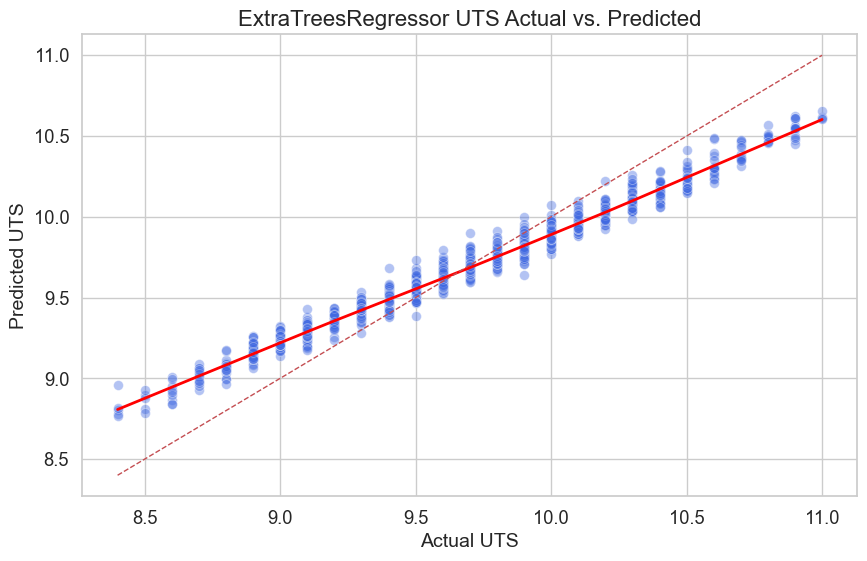

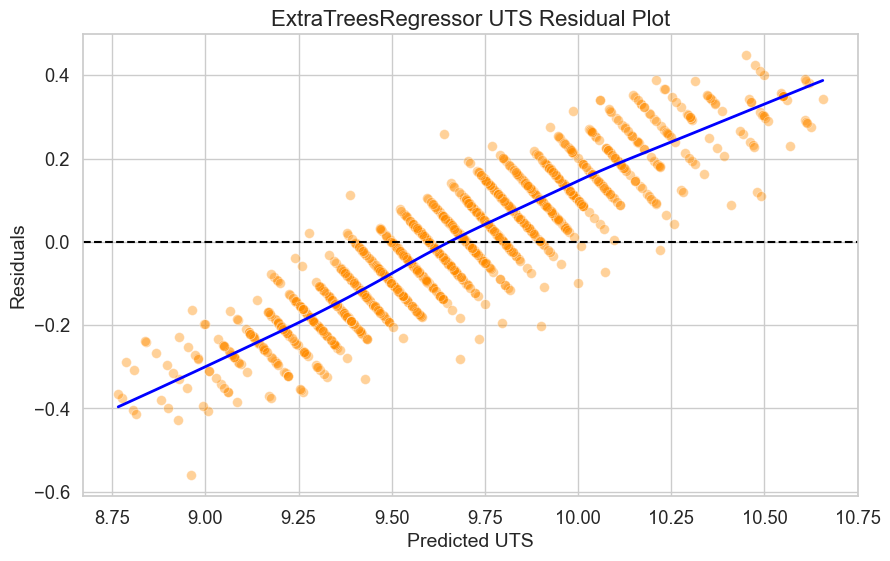

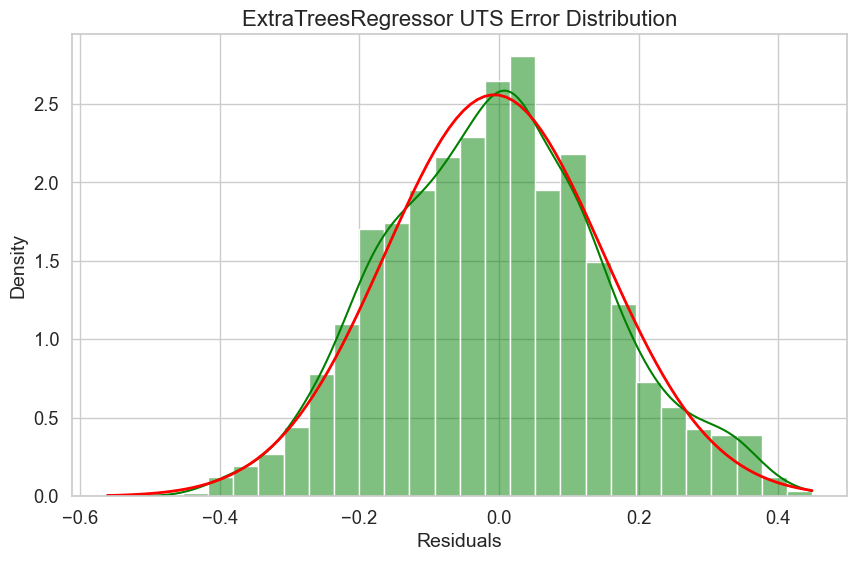

C:\Users\DELL\AppData\Local\Temp\ipykernel_17520\2143246887.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")


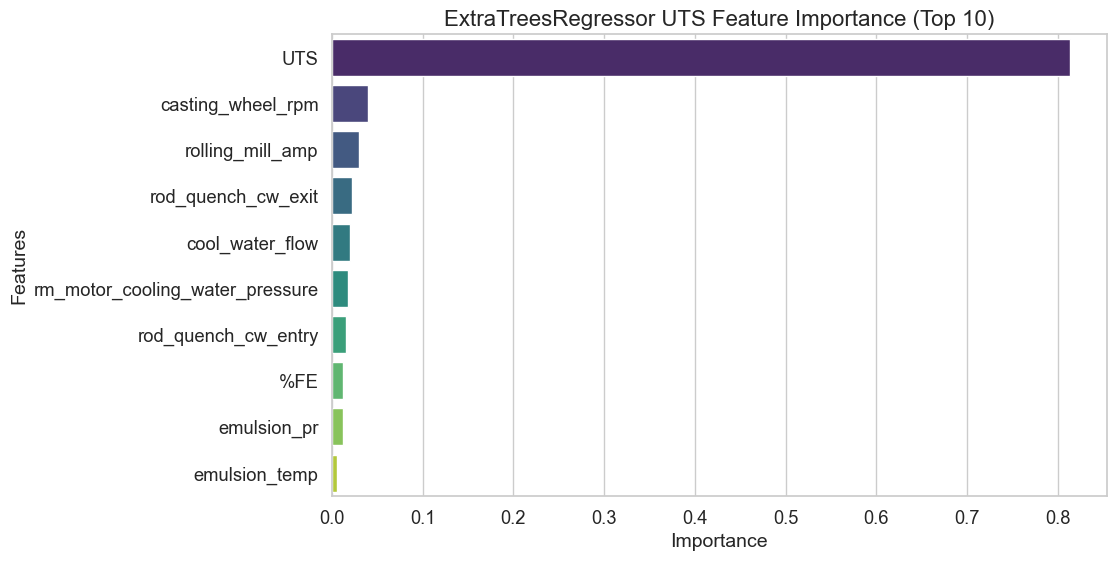

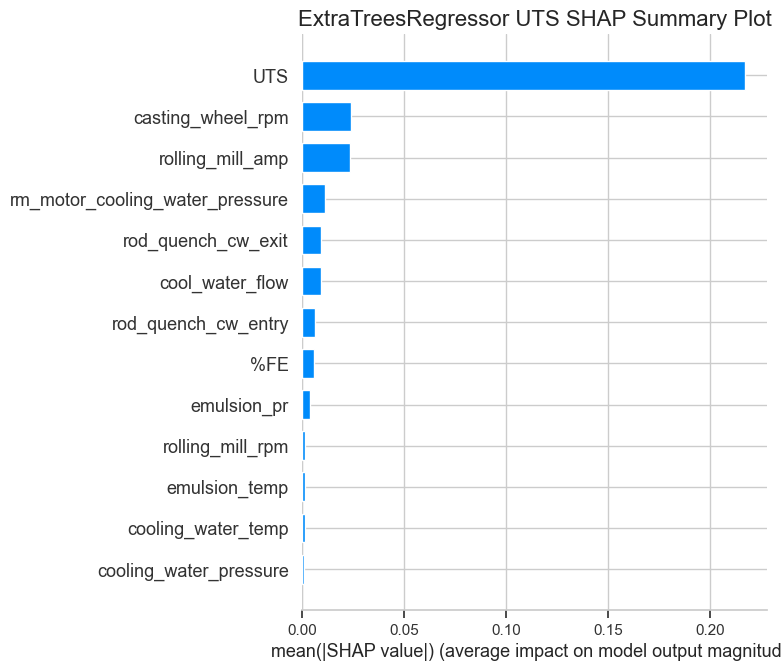

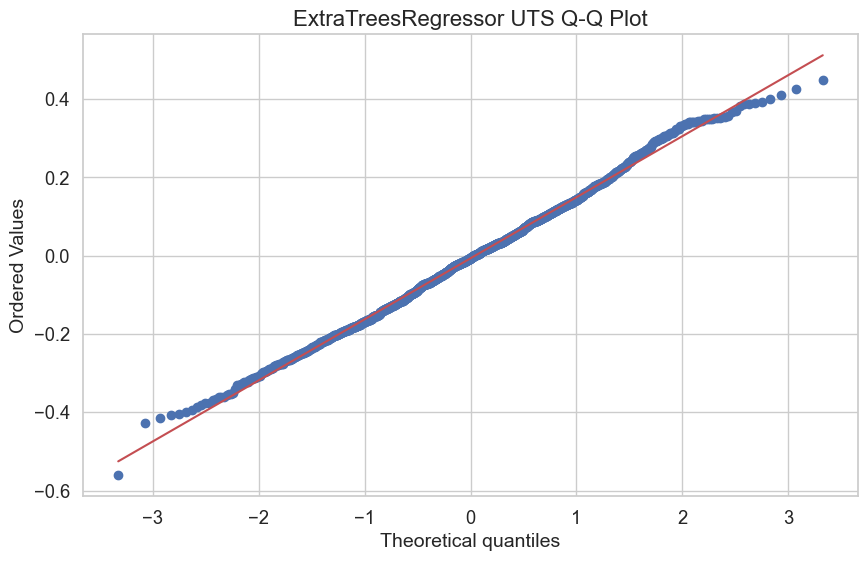

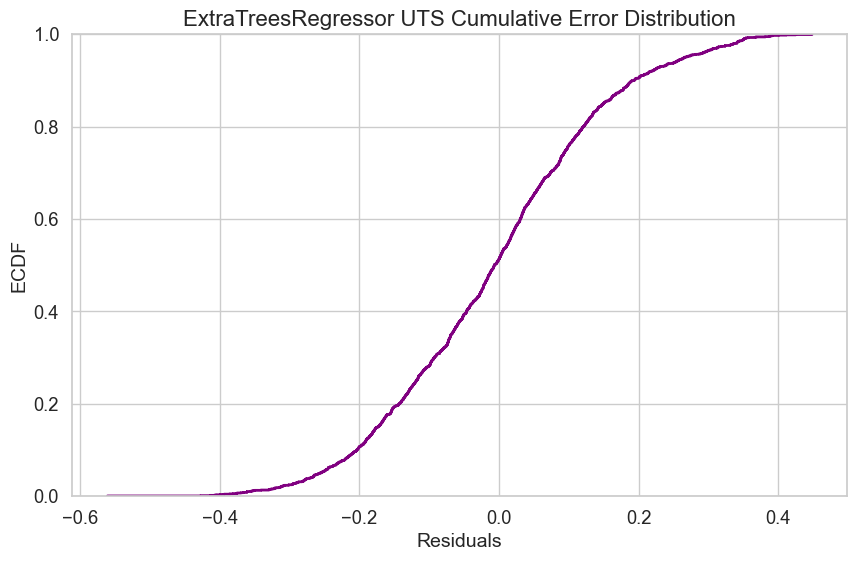

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df = df.drop_duplicates()

# ✅ Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ✅ Define columns to exclude
columns_to_exclude = ["elongation", "Conductivity", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]  # Target variable UTS

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define Extra Trees hyperparameters
params_uts = {
    "n_estimators": 250,  # Number of trees
    "max_depth": 12,  # Depth of each tree
    "min_samples_split": 4,  # Minimum samples required to split a node
    "min_samples_leaf": 2,  # Minimum samples at a leaf node
    "max_features": "sqrt",  # Maximum features for splitting
    "bootstrap": False,  # No bootstrapping
    "random_state": 42,
    "n_jobs": -1  # Utilize all CPU cores
}

# ✅ Train Extra Trees model for UTS
et_model_uts = ExtraTreesRegressor(**params_uts)
et_model_uts.fit(X_train, y_train)

# ✅ Predictions
y_test_pred = et_model_uts.predict(X_test)

# ✅ Compute Final R² Score and Extra Metrics
r2 = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# ✅ Print Final Metrics
print("\n🔹 Extra Trees for UTS Regression Metrics:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# ✅ Visualizations
output_dir = "extratreesregressor_UTS_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Actual vs Predicted Scatter Plot with LOESS curve
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("ExtraTreesRegressor UTS Actual vs. Predicted")
plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.savefig(f"{output_dir}/ETR_UTS_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Residual Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("ExtraTreesRegressor UTS Residual Plot")
plt.xlabel("Predicted UTS")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/ETR_UTS_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("ExtraTreesRegressor UTS Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/ETR_UTS_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Learning Curves (Training vs. Validation RMSE)
# Extra Trees does not have direct learning curve functionality, but you can simulate it using cross-validation and tracking RMSE.
# For simplicity, we will skip this visualization in this example.

# 5. Hyperparameter vs. Error Plot
# Hyperparameters tuning (learning rates are not applicable for ExtraTrees), you may consider grid search for other hyperparameters.

# 6. Feature Importance Plot
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": et_model_uts.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
plt.title("ExtraTreesRegressor UTS Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir}/ETR_UTS_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. SHAP Summary Plot
explainer = shap.TreeExplainer(et_model_uts)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("ExtraTreesRegressor UTS SHAP Summary Plot")
plt.savefig(f"{output_dir}/ETR_UTS_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("ExtraTreesRegressor UTS Q-Q Plot")
plt.savefig(f"{output_dir}/ETR_UTS_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("ExtraTreesRegressor UTS Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/ETR_UTS_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()